# 여러 가지 정적분에 관한 문제

정적분을 **급수의 극한**(리만합)으로 보고, 반대로 급수를 정적분으로 바꾼다.

$$
\int_a^b f(x)\,dx = \lim_{n\to\infty}\sum_{k=1}^{n} f(x_k^*)\Delta x
$$

## 1. 정적분과 급수 — 리만합

$[0,1]$에서 $\Delta x=1/n$, $x_k=k/n$:

$$
\int_0^1 x^2\,dx = \lim_{n\to\infty}\sum_{k=1}^{n}\left(\frac{k}{n}\right)^2\frac{1}{n}
$$


부분합 S_n =


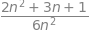

lim S_n =


정적분:


In [4]:
import sympy as sp
from sympy.series.limitseq import limit_seq

sp.init_printing()
n, k = sp.symbols('n k', integer=True, positive=True)
x = sp.symbols('x')

# 오른쪽 리만합
riemann = sp.Sum((k/n)**2 * (1/n), (k, 1, n))
S_n = sp.simplify(riemann.doit())
print("부분합 S_n =")
display(S_n)

try:
    L = sp.limit(S_n, n, sp.oo)
except NotImplementedError:
    L = limit_seq(S_n, n)

print("lim S_n =")
display(L)
print("정적분:")
display(sp.integrate(x**2, (x, 0, 1)))


## 시각화: 리만 직사각형 ($n$이 커지면 적분에 접근)

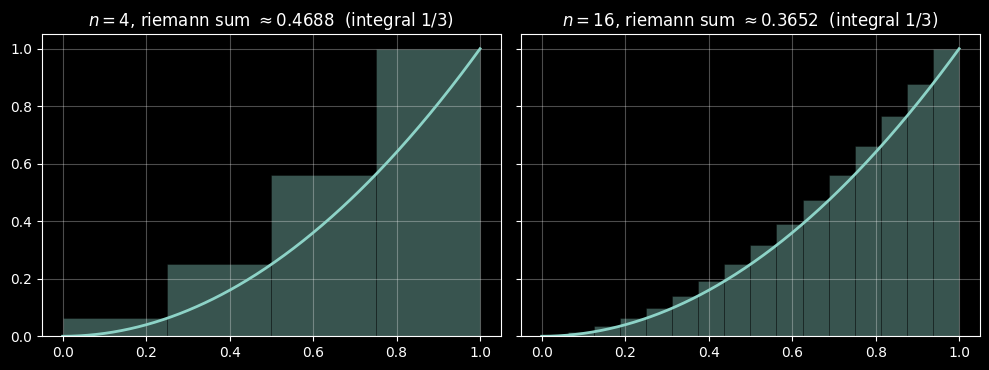

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def riemann_plot(ax, n, a=0.0, b=1.0):
    xs = np.linspace(a, b, 400)
    ax.plot(xs, xs**2, color="C0", lw=2)
    dx = (b - a) / n
    left = np.linspace(a, b - dx, n)
    # 오른쪽 끝점: x_k^* = a + k dx
    heights = (left + dx) ** 2
    ax.bar(left, heights, width=dx, align="edge", alpha=0.4, edgecolor="k", linewidth=0.6)
    area = np.sum(heights * dx)
    ax.set_title(rf"$n={n}$, riemann sum $\approx {area:.4f}$  (integral $1/3$)")
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
riemann_plot(axes[0], 4)
riemann_plot(axes[1], 16)
plt.tight_layout()
plt.show()

**sp.Sum(...).doit()**: <br>
=> 부분합을 닫힌 식으로

**주의**: $(-1)^n$이 들어가면 `sp.limit` 대신 `limit_seq`.


## 2. 급수 → 정적분으로 읽기

$$
\lim_{n\to\infty}\sum_{k=1}^{n} f\!\left(\frac{k}{n}\right)\frac{1}{n} = \int_0^1 f(x)\,dx
$$


In [6]:
examples = [
    ("Σ (k/n) · (1/n)", k/n),
    ("Σ (k/n)² · (1/n)", (k/n)**2),
    ("Σ sin(kπ/n) · (1/n)", sp.sin(k*sp.pi/n)),
]

for name, term in examples:
    S_n = sp.simplify(sp.Sum(term/n, (k, 1, n)).doit())
    try:
        L = sp.limit(S_n, n, sp.oo)
    except NotImplementedError:
        L = limit_seq(S_n, n)
    print("=" * 40)
    print(name)
    print("lim =", L)


Σ (k/n) · (1/n)
lim = 1/2
Σ (k/n)² · (1/n)
lim = 1/3
Σ sin(kπ/n) · (1/n)
lim = 0


## 3. 공식으로 검산

$\sum k = n(n+1)/2$, $\sum k^2 = n(n+1)(2n+1)/6$ 을 쓰면 리만합 극한을 손으로도 구할 수 있음


n^{-3} Σ k² =


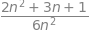

극한:


In [7]:
# Σ_{k=1}^n (k/n)² (1/n) = n^{-3} Σ k²
closed = sp.simplify(sp.summation(k**2, (k, 1, n)) / n**3)
print("n^{-3} Σ k² =")
display(closed)
print("극한:")
display(sp.limit(closed, n, sp.oo))
